--- STARTING IN-DEPTH VISUALIZATIONS FOR BRUSSELS ---
--- LOADING AGGREGATED DATA ---


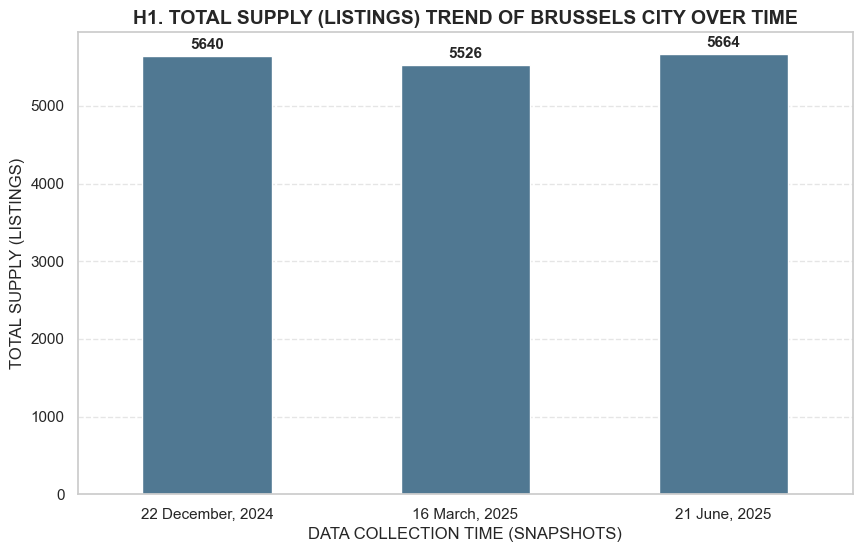

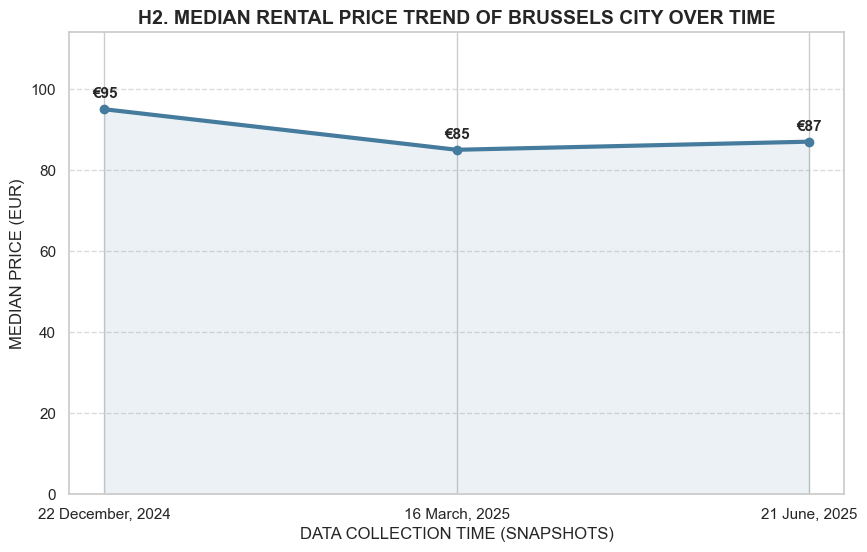

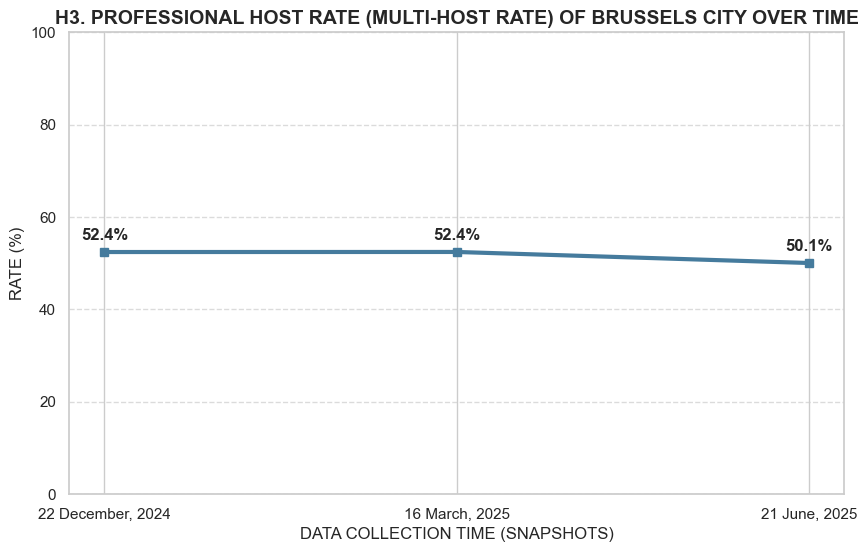

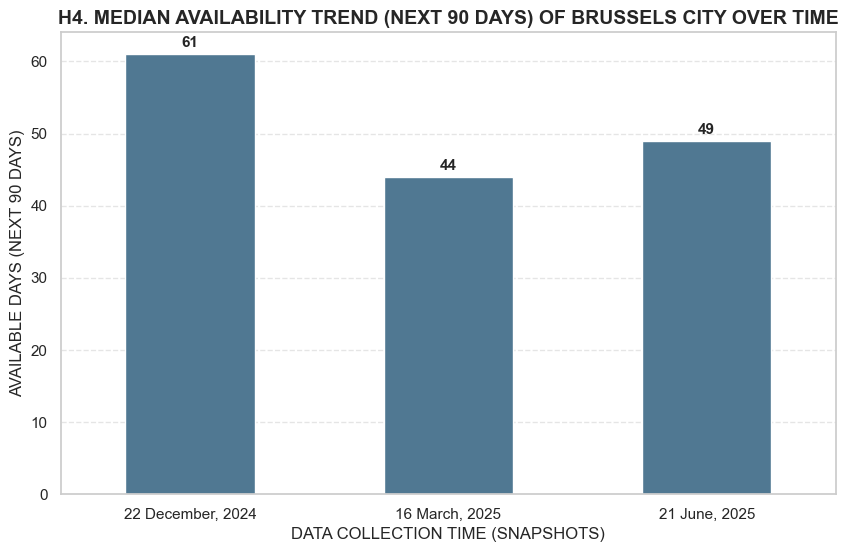

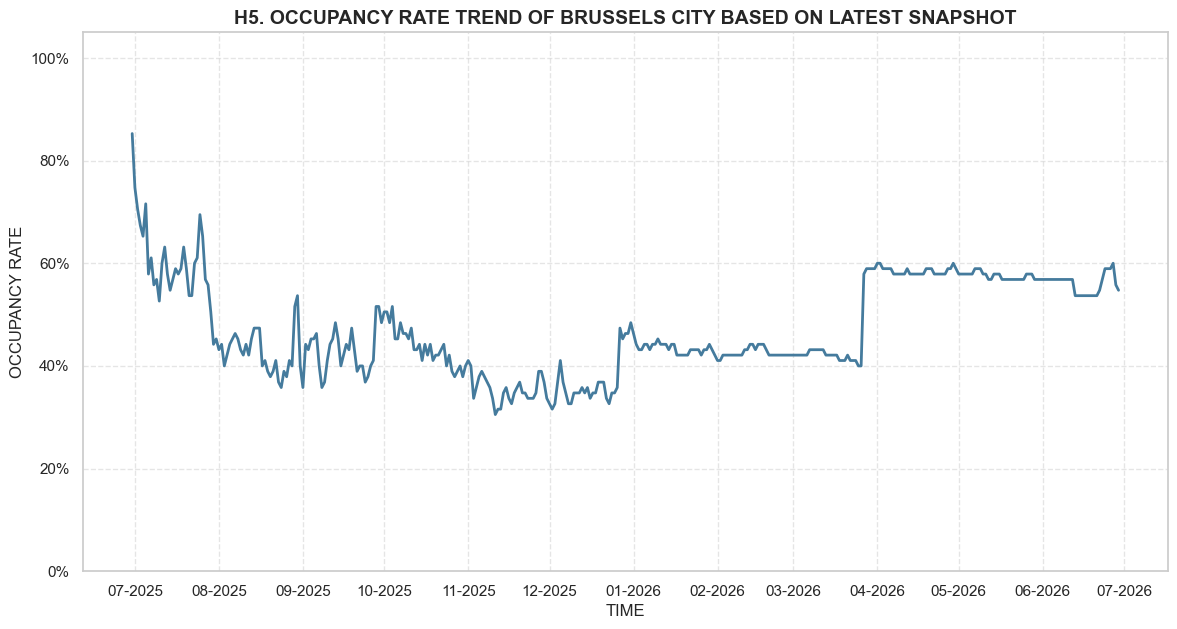

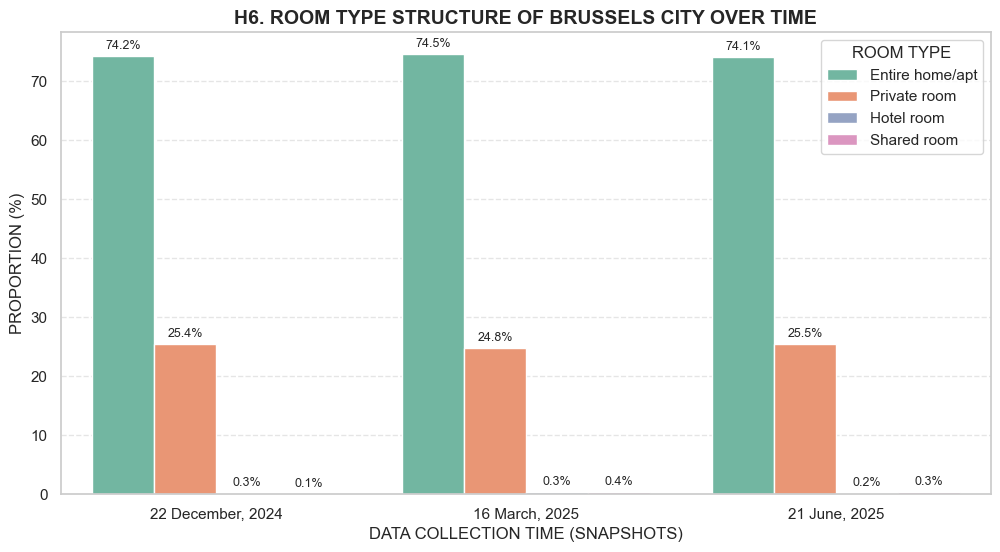

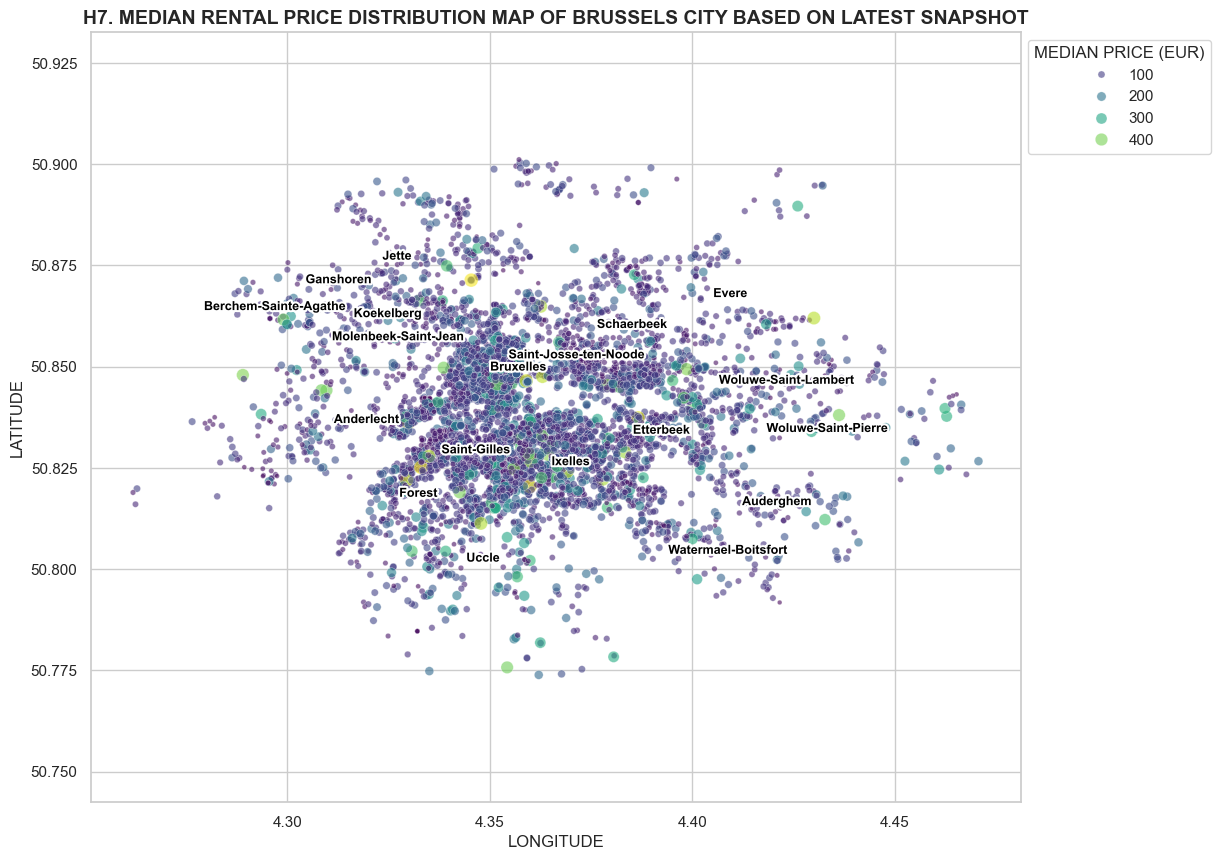

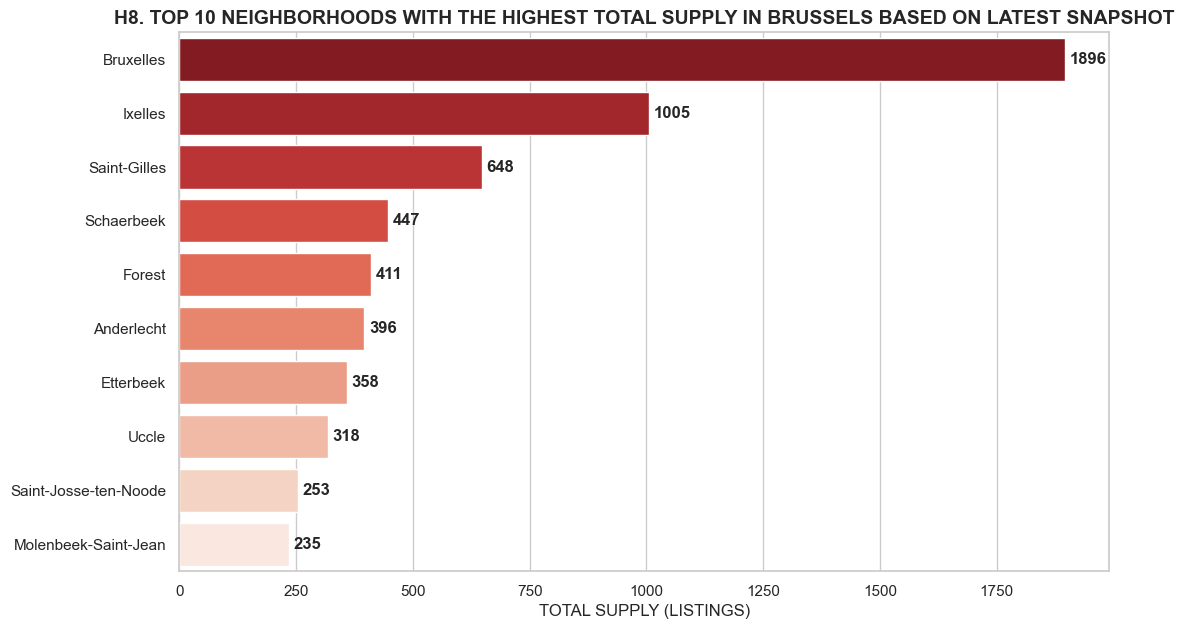

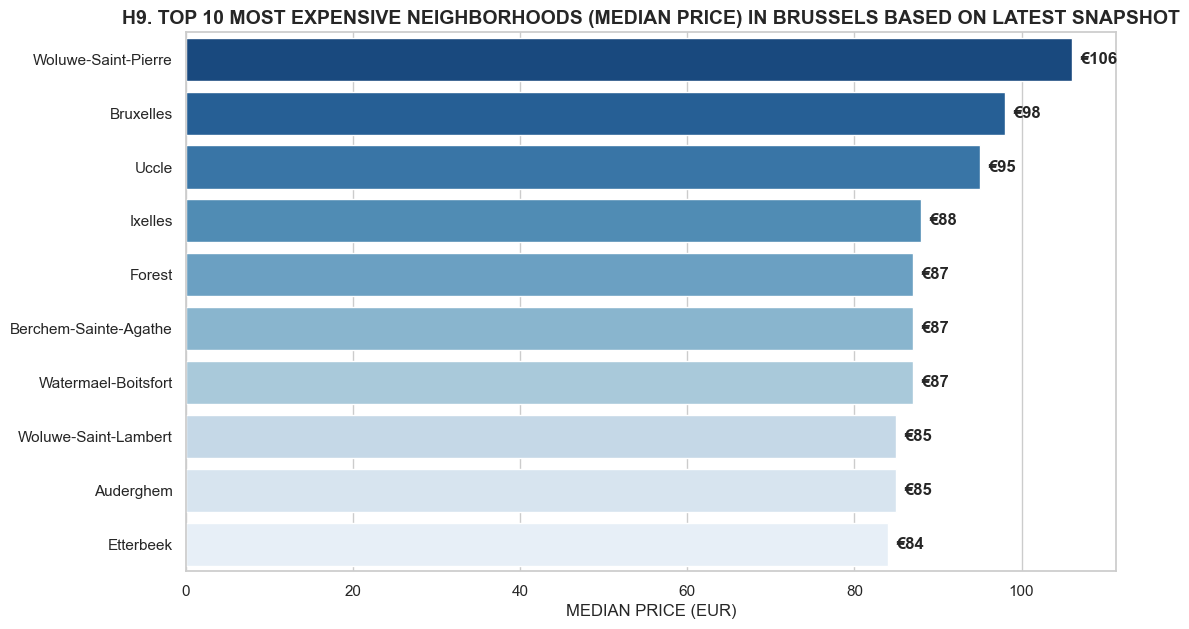

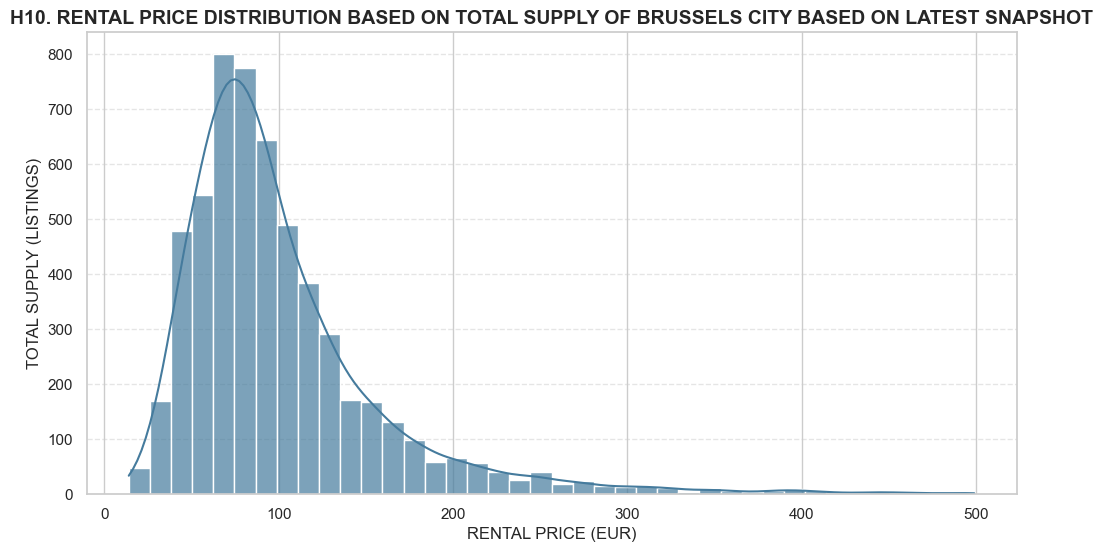

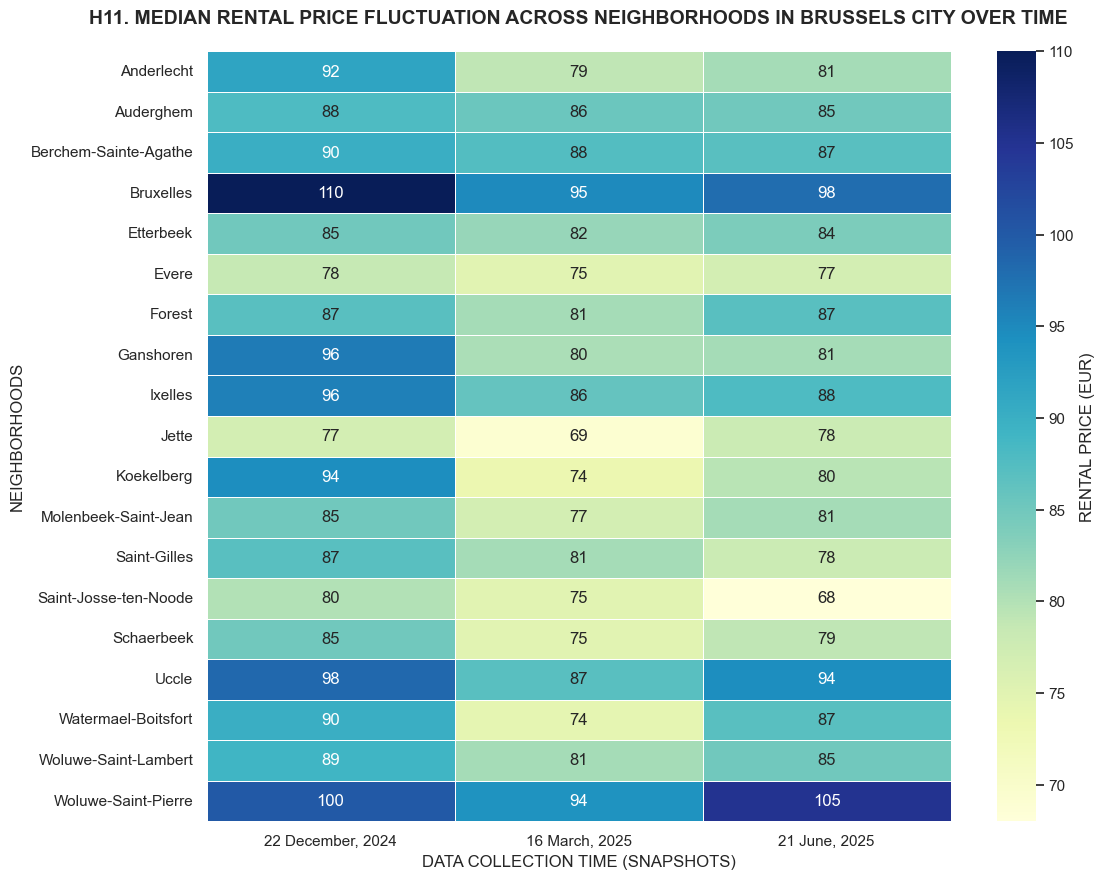

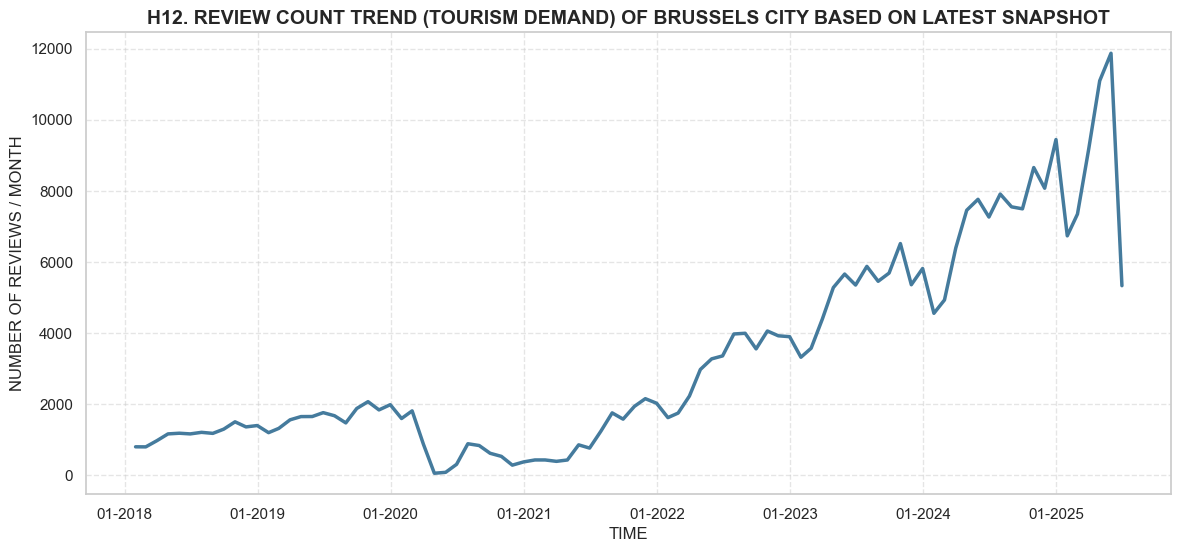

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as PathEffects
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

# --- 1. CONFIGURATION ---
sns.set_theme(style="whitegrid")
BASE_DIR = '..'
PROCESSED_DIR = os.path.join(BASE_DIR, 'processed', 'brussels')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
CITY_SUFFIX = 'brussels'

print("--- STARTING IN-DEPTH VISUALIZATIONS FOR BRUSSELS ---")

# --- ADDITION: LOAD NEW KPI FILES ---
try:
    kpi_neigh = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_neighbourhood_{CITY_SUFFIX}.csv'))
    kpi_review = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_reviews_trend_{CITY_SUFFIX}.csv'))
except FileNotFoundError:
    kpi_neigh = pd.DataFrame()
    kpi_review = pd.DataFrame()


# --- 2. LOAD KPI DATA ---
try:
    # Load generated KPI files
    kpi_supply = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_summary_general_{CITY_SUFFIX}.csv'))
    kpi_room = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_room_type_{CITY_SUFFIX}.csv'))
    kpi_season = pd.read_csv(os.path.join(PROCESSED_DIR, f'kpi_seasonality_{CITY_SUFFIX}.csv'))

    # Function to sort by date
    def sort_by_date(df, date_col='snapshot_date'):
        df['dt'] = pd.to_datetime(df[date_col], errors='coerce')
        return df.sort_values('dt')

    kpi_supply = sort_by_date(kpi_supply)
    # kpi_room and kpi_season will be processed separately when plotting
    print("--- LOADING AGGREGATED DATA ---")
except FileNotFoundError as e:
    print(f" Error: KPI files not found. Details: {e}")
    kpi_supply = pd.DataFrame() # Create empty dataframe to prevent crashes

# --- 3. LOAD DETAILED DATA (LATEST SNAPSHOT) ---
from datetime import datetime

def parse_snapshot_name(name):
    """
    Parse snapshot folder name like '21 June, 2025' into datetime.
    Returns None if parsing fails.
    """
    try:
        return datetime.strptime(name.strip(), "%d %B, %Y")
    except:
        return None

df_detail = pd.DataFrame()
LATEST_SNAPSHOT = "Unknown"

if os.path.exists(PROCESSED_DIR):

    # Get directory list + keep only directories with valid date formats
    raw_snaps = [
        d for d in os.listdir(PROCESSED_DIR)
        if os.path.isdir(os.path.join(PROCESSED_DIR, d))
    ]

    # Parse + keep valid snapshots
    snapshots = [s for s in raw_snaps if parse_snapshot_name(s) is not None]

    # Sort by date (newest first)
    snapshots = sorted(
        snapshots,
        key=lambda x: parse_snapshot_name(x),
        reverse=True
    )

    # Get the latest file
    for snap in snapshots:
        file_path = os.path.join(PROCESSED_DIR, snap, 'listings_processed.csv')
        if os.path.exists(file_path):
            try:
                temp = pd.read_csv(file_path, low_memory=False)
                if not temp.empty and 'price_numeric' in temp.columns:
                    df_detail = temp
                    LATEST_SNAPSHOT = snap
                    break
            except:
                continue


# --- 4. PLOTTING CHARTS ---

# === H1: Supply Trend (Bar Chart) ===
if not kpi_supply.empty:
    plt.figure(figsize=(10, 6))
    ax1 = sns.barplot(data=kpi_supply, x='snapshot_date', y='total_listings', color='#457B9D', width=0.5)
    plt.title('H1. TOTAL SUPPLY (LISTINGS) TREND OF BRUSSELS CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('TOTAL SUPPLY (LISTINGS)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for i in ax1.containers: ax1.bar_label(i, padding=3, fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_01_supply.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H2: Price Trend (Line/Area Chart) ===
if not kpi_supply.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(kpi_supply['snapshot_date'], kpi_supply['median_price'], marker='o', linewidth=3, color='#457B9D')
    plt.fill_between(kpi_supply['snapshot_date'], kpi_supply['median_price'], color='#457B9D', alpha=0.1)
    plt.title('H2. MEDIAN RENTAL PRICE TREND OF BRUSSELS CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('MEDIAN PRICE (EUR)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for x, y in zip(kpi_supply['snapshot_date'], kpi_supply['median_price']):
        plt.text(x, y + 2, f"€{y:.0f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.ylim(bottom=0, top=kpi_supply['median_price'].max()*1.2)
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_02_price.pdf'), format='pdf', bbox_inches='tight')
    plt.show()

# === H3: PROFESSIONAL HOST RATE TREND (MULTI-HOST RATE) ===
if not kpi_supply.empty and 'multi_host_rate' in kpi_supply.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(kpi_supply['snapshot_date'], kpi_supply['multi_host_rate'], marker='s', linewidth=3, color='#457B9D')
    
    plt.title(f'H3. PROFESSIONAL HOST RATE (MULTI-HOST RATE) OF {CITY_SUFFIX.upper()} CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('RATE (%)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, 100) # Rate is always on a 0-100 scale
    
    # Display % values on points
    for x, y in zip(kpi_supply['snapshot_date'], kpi_supply['multi_host_rate']):
        plt.text(x, y + 2, f"{y:.1f}%", ha='center', va='bottom', fontweight='bold')
        
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_03_multi_host.pdf'), format='pdf', bbox_inches='tight')
    plt.show()



# === H4: MEDIAN AVAILABILITY TREND (AVAILABILITY 90) ===
if not kpi_supply.empty and 'median_avail_90' in kpi_supply.columns:
    plt.figure(figsize=(10, 6))
    ax12 = sns.barplot(data=kpi_supply, x='snapshot_date', y='median_avail_90', color='#457B9D', width=0.5)
    
    plt.title(f'H4. MEDIAN AVAILABILITY TREND (NEXT 90 DAYS) OF {CITY_SUFFIX.upper()} CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('AVAILABLE DAYS (NEXT 90 DAYS)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Label
    for i in ax12.containers: ax12.bar_label(i, padding=3, fontsize=11, fontweight='bold')
        
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_04_availability.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H5: Occupancy Rate Trend (Line Chart) ===
if not kpi_season.empty:
    df_h5 = kpi_season.copy()
    # Convert dates
    df_h5['date_dt'] = pd.to_datetime(df_h5['date'], errors='coerce')
    df_h5['snapshot_dt'] = pd.to_datetime(df_h5['snapshot_date'], errors='coerce')
    
    # Get data from the LATEST snapshot
    latest_snap_dt = df_h5['snapshot_dt'].max()
    df_final_h5 = df_h5[df_h5['snapshot_dt'] == latest_snap_dt].sort_values('date_dt')

    if not df_final_h5.empty:
        plt.figure(figsize=(14, 7))
        sns.lineplot(data=df_final_h5, x='date_dt', y='occupancy_rate', color='#457B9D', linewidth=2)
        
        # Format axes
        plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))

        plt.title(f'H5. OCCUPANCY RATE TREND OF BRUSSELS CITY BASED ON LATEST SNAPSHOT', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('OCCUPANCY RATE')
        plt.xlabel('TIME')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(0, 1.05)
        
        
        plt.savefig(os.path.join(FIGURES_DIR, 'brussels_05_occupancy.pdf'), format='pdf', bbox_inches='tight')
        plt.show()
        
    else:
        print("   ! No occupancy data for the latest snapshot.")
else:
    print("   ! No seasonality data available.")


# === H6: Room Type Structure (Grouped Bar) ===
if not kpi_room.empty:
    plt.figure(figsize=(12, 6))
    kpi_room['dt'] = pd.to_datetime(kpi_room['snapshot_date'], errors='coerce')
    kpi_room = kpi_room.sort_values('dt')
    
    ax3 = sns.barplot(data=kpi_room, x='snapshot_date', y='percentage', hue='room_type', palette='Set2')
    plt.title('H6. ROOM TYPE STRUCTURE OF BRUSSELS CITY OVER TIME', fontsize=14, fontweight='bold')
    plt.ylabel('PROPORTION (%)')
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.legend(title='ROOM TYPE', bbox_to_anchor=(1, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    for i in ax3.containers: ax3.bar_label(i, fmt='%.1f%%', padding=3, fontsize=9)
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_06_room_type.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H7: Listing Distribution Map (Scatter Map) ===
if not df_detail.empty and 'latitude' in df_detail.columns:
    plt.figure(figsize=(12, 10))
    
    # Draw points (filter price < 500)
    sns.scatterplot(
        data=df_detail[df_detail['price_numeric'] < 500], 
        x='longitude', y='latitude', 
        hue='price_numeric', palette='viridis', 
        size='price_numeric', sizes=(10, 100), alpha=0.6,
        legend='brief'
    )

    # Add neighborhood name labels
    if 'neighbourhood_cleansed' in df_detail.columns:
        neigh_centers = df_detail.groupby('neighbourhood_cleansed')[['latitude', 'longitude']].mean().reset_index()
        for i, row in neigh_centers.iterrows():
            txt = plt.text(
                row['longitude'], row['latitude'], 
                row['neighbourhood_cleansed'], 
                fontsize=9, fontweight='bold', color='black',
                ha='center', va='center'
            )
            txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])

    plt.title(f'H7. MEDIAN RENTAL PRICE DISTRIBUTION MAP OF BRUSSELS CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('LONGITUDE')
    plt.ylabel('LATITUDE')
    plt.legend(title='MEDIAN PRICE (EUR)', bbox_to_anchor=(1, 1), loc='upper left')
    plt.axis('equal') 
    
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_07_map_labeled.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    

# === H8: TOP 10 NEIGHBORHOODS WITH THE MOST LISTINGS ===
if not df_detail.empty and 'neighbourhood_cleansed' in df_detail.columns:
    top_supply_neigh = df_detail['neighbourhood_cleansed'].value_counts().head(10).reset_index()
    top_supply_neigh.columns = ['neighbourhood_cleansed', 'count']

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=top_supply_neigh,
        y='neighbourhood_cleansed',
        x='count',
        palette='Reds_r',
        hue='neighbourhood_cleansed',
        legend=False
    )
    plt.title(f'H8. TOP 10 NEIGHBORHOODS WITH THE HIGHEST TOTAL SUPPLY IN BRUSSELS BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('TOTAL SUPPLY (LISTINGS)')
    plt.ylabel('')
    for i, v in enumerate(top_supply_neigh['count']):
        plt.text(v + 10, i, f"{v}", va='center', fontweight='bold')
        
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_08_top10_supply.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H9: Top 10 Most Expensive Neighborhoods (Bar Chart) ===
if not df_detail.empty and 'neighbourhood_cleansed' in df_detail.columns:
    neigh_price = df_detail.groupby('neighbourhood_cleansed')['price_numeric'].median().sort_values(ascending=False).head(10).reset_index()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=neigh_price, 
        y='neighbourhood_cleansed', 
        x='price_numeric', 
        palette='Blues_r', 
        hue='neighbourhood_cleansed', 
        legend=False
    )
    plt.title(f'H9. TOP 10 MOST EXPENSIVE NEIGHBORHOODS (MEDIAN PRICE) IN BRUSSELS BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.xlabel('MEDIAN PRICE (EUR)')
    plt.ylabel('')
    for i, v in enumerate(neigh_price['price_numeric']):
        plt.text(v + 1, i, f"€{v:.0f}", va='center', fontweight='bold')
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_09_top10_price.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
    


# === H10: RENTAL PRICE DISTRIBUTION (HISTOGRAM + KDE) ===
if not df_detail.empty and 'price_numeric' in df_detail.columns:
    plt.figure(figsize=(12, 6))
    
    sns.histplot(
        df_detail[df_detail['price_numeric'] < 500]['price_numeric'],
        kde=True,
        bins=40,
        color='#457B9D',
        alpha=0.7
    )
    
    plt.title(f'H10. RENTAL PRICE DISTRIBUTION BASED ON TOTAL SUPPLY OF BRUSSELS CITY BASED ON LATEST SNAPSHOT',
              fontsize=14, fontweight='bold')
    plt.xlabel('RENTAL PRICE (EUR)')
    plt.ylabel('TOTAL SUPPLY (LISTINGS)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_10_price_distribution.pdf'), 
                format='pdf', bbox_inches='tight')
    plt.show()
    


# === H11: REGIONAL PRICE FLUCTUATION HEATMAP (OPTIMIZED VERSION) ===
if not kpi_neigh.empty:
    # 1. Filter Top 20 neighborhoods with the most listings (to avoid a cluttered Heatmap)
    top_areas = kpi_neigh.groupby('neighbourhood')['listing_count'].sum().sort_values(ascending=False).head(20).index
    df_heat = kpi_neigh[kpi_neigh['neighbourhood'].isin(top_areas)].copy()
    
    # 2. Pivot the table
    heatmap_data = df_heat.pivot_table(index='neighbourhood', columns='snapshot_date', values='median_price')
    
    # 3. Sort columns by time
    sorted_cols = sorted(heatmap_data.columns, key=parse_snapshot_name)
    heatmap_data = heatmap_data[sorted_cols]

    # 4. Draw Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'RENTAL PRICE (EUR)'})
    
    plt.title(f'H11. MEDIAN RENTAL PRICE FLUCTUATION ACROSS NEIGHBORHOODS IN {CITY_SUFFIX.upper()} CITY OVER TIME', fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('DATA COLLECTION TIME (SNAPSHOTS)')
    plt.ylabel('NEIGHBORHOODS')
    
    plt.savefig(os.path.join(FIGURES_DIR, f'{CITY_SUFFIX}_11_price_heatmap_optimized.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
else:
    print(" No KPI Neighbourhood data to draw H11.")



# === H12: REVIEW COUNT TREND (TOURISM DEMAND) ===
if not kpi_review.empty:
    plt.figure(figsize=(14, 6))
    
    # 1. Find the latest snapshot (Most accurate logic)
    kpi_review['snap_dt'] = pd.to_datetime(kpi_review['snapshot_date'], errors='coerce')
    latest_snap_date = kpi_review['snap_dt'].max()
    
    # 2. Filter review data for that snapshot only
    df_rev_final = kpi_review[kpi_review['snap_dt'] == latest_snap_date].copy()
    
    # 3. Process dates
    df_rev_final['date'] = pd.to_datetime(df_rev_final['date'])
    df_rev_final = df_rev_final.sort_values('date')
    
    # 4. Filter years (2018 and later)
    df_rev_final = df_rev_final[df_rev_final['date'].dt.year >= 2018]

    # 5. Plot
    sns.lineplot(data=df_rev_final, x='date', y='review_count', color='#457B9D', linewidth=2.5)
    
    plt.title(f'H12. REVIEW COUNT TREND (TOURISM DEMAND) OF {CITY_SUFFIX.upper()} CITY BASED ON LATEST SNAPSHOT', fontsize=14, fontweight='bold')
    plt.ylabel('NUMBER OF REVIEWS / MONTH')
    plt.xlabel('TIME')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    
    plt.savefig(os.path.join(FIGURES_DIR, 'brussels_12_reviews_trend.pdf'), format='pdf', bbox_inches='tight')
    plt.show()
else:
    print(" No Review Trend data available to draw H12.")